In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("train (1).csv")
df.tail()

,1.126727,47.743884
64,-1.500082,414.076341
65,0.493507,-34.616994
66,1.725494,573.001536
67,0.872540,18.485251
68,0.725811,-16.120312


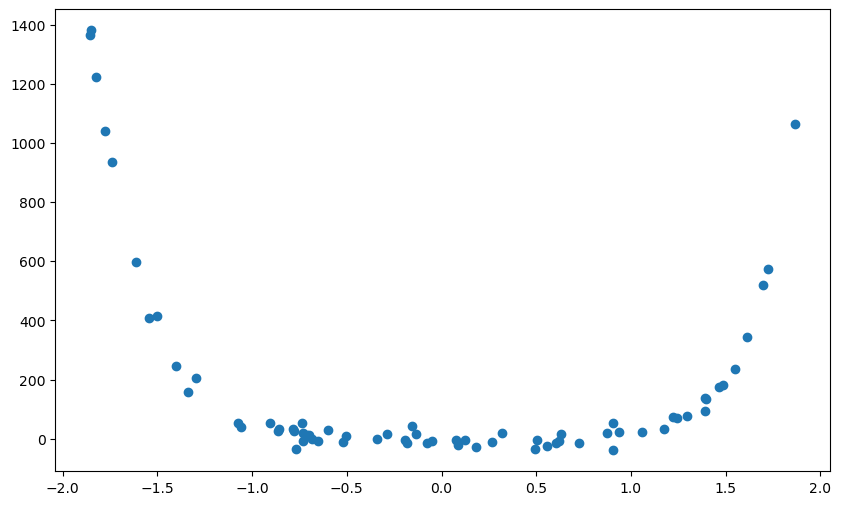

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.show()

In [5]:
#Applying Gradiant Descent for polynomial regression
x_train, y_train = df.iloc[:, 0].values, df.iloc[:, 1].values
lr = 0.00001 #learning rate

for d in range(4, 12):
    X_train=np.column_stack([x_train**i for i in range(0, d+1)])
    A = np.zeros(d+1) #initializing coefficients
    for i in range(100000):
        A = A - lr * (X_train.T @ (X_train @ A - y_train)) / len(X_train)
    y_pred = X_train @ A
    r2 = 1 - np.sum((y_train - y_pred)**2) / np.sum((y_train - np.mean(y_train))**2)
    adjusted_r2 = 1 - (1 - r2) * (len(y_train) - 1) / (len(y_train) - d - 1)
    print(f"Degree: {d}, Adjusted R2 Score: {adjusted_r2}")
    print(f"Number of features: {len(X_train)}")
  



Degree: 4, Adjusted R2 Score: 0.9490887299808834
Number of features: 69
Degree: 5, Adjusted R2 Score: 0.9479880581724293
Number of features: 69
Degree: 6, Adjusted R2 Score: 0.9938942469001273
Number of features: 69
Degree: 7, Adjusted R2 Score: 0.993948018845965
Number of features: 69
Degree: 8, Adjusted R2 Score: 0.9957481988402751
Number of features: 69
Degree: 9, Adjusted R2 Score: 0.9958575338816384
Number of features: 69
Degree: 10, Adjusted R2 Score: 0.9956533512137182
Number of features: 69
Degree: 11, Adjusted R2 Score: 0.9955254533922472
Number of features: 69


In [6]:
X=np.column_stack([x_train**i for i in range(0,10)])
L=X.T @ X
R=X.T @ y_train
A=np.linalg.solve(L,R)

In [7]:
#Polynomial is

print("Polynomial equation: y =", " + ".join([f"{coef:.4f}*x^{i}" for i, coef in enumerate(A)]))

Polynomial equation: y = -4.3311*x^0 + -38.7136*x^1 + 2.2055*x^2 + 92.2036*x^3 + 30.7287*x^4 + -84.7318*x^5 + -4.9280*x^6 + 22.1237*x^7 + 7.3825*x^8 + -1.9671*x^9


In [8]:
dt=pd.read_csv("test.csv")
dt.head()

,-1.819228,1255.525442
0,0.349282,18.559193
1,0.442694,-2.665981
2,0.044696,-3.456760
3,1.419504,131.568324
4,-0.577323,34.867037


Predicted values for test set:


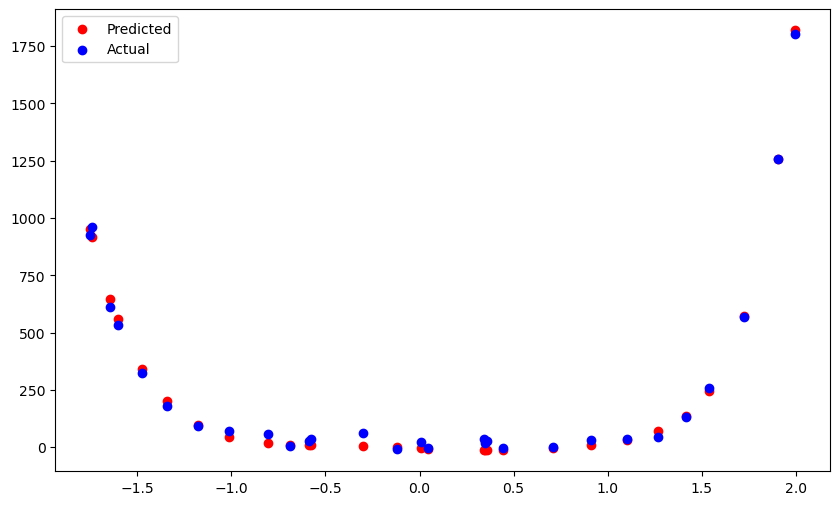

In [9]:
x_test=dt.iloc[:, 0].values
y_test=dt.iloc[:, 1].values
X_test=np.column_stack([x_test**i for i in range(0,10)])
y_test_pred=X_test @ A

print("Predicted values for test set:")
plt.figure(figsize=(10,6))
plt.scatter(x_test, y_test_pred, color='red', label='Predicted')
plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.legend()
plt.show()

In [10]:
mse=np.mean((y_test - y_test_pred)**2)
print("Mean Squared Error on test set:", mse)

Mean Squared Error on test set: 657.2247509441336


In [11]:
indices = np.arange(len(df))
np.random.shuffle(indices)
train_idx, val_idx = indices[:int(0.8*len(df))], indices[int(0.8*len(df)):]
x_train, y_train = df.iloc[train_idx, 0].values, df.iloc[train_idx, 1].values
x_val, y_val = df.iloc[val_idx, 0].values, df.iloc[val_idx, 1].values

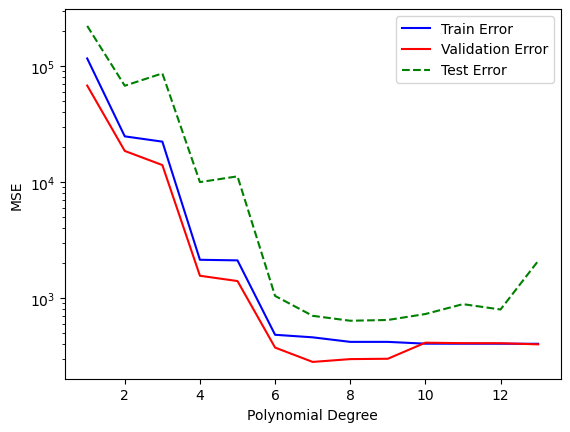

In [12]:
#Validation curves for polynomial degrees 1 to 14
degrees = range(1, 14)
train_errs, val_errs, test_errs = [], [], []

for d in degrees:
    X_train=np.column_stack([x_train**i for i in range(0, d+1)])
    X_val=np.column_stack([x_val**i for i in range(0, d+1)])
    A=np.linalg.pinv(X_train) @ y_train
    #Calculating MSE for train and validation sets
    train_errs.append(np.mean((X_train @ A - y_train)**2))
    val_errs.append(np.mean((X_val @ A - y_val)**2))
    X_test=np.column_stack([x_test**i for i in range(0, d+1)])
    test_err=np.mean((X_test @ A - y_test)**2)
    test_errs.append(test_err)


plt.plot(degrees, train_errs, label='Train Error', color='blue')
plt.plot(degrees, val_errs, label='Validation Error', color='red')
plt.plot(degrees, test_errs, label='Test Error', color='green', linestyle='--')
plt.yscale('log')
plt.xlabel('Polynomial Degree'), plt.ylabel('MSE'), plt.legend()
plt.show()

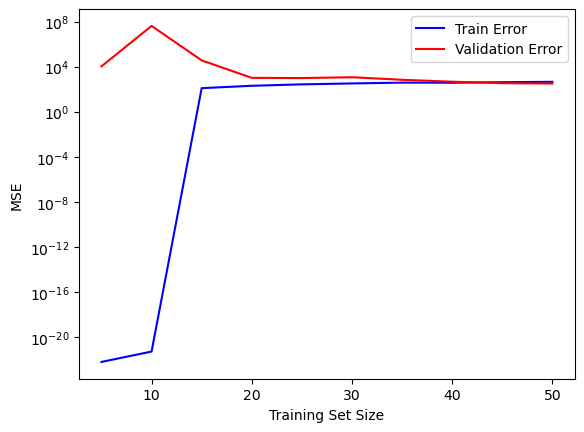

In [13]:
#Learning curves for polynomial degree 9, MSE vs training set size
d=9
m_sizes=range(5, len(x_train), 5)
train_errs = []
val_errs = []

for m in m_sizes:
    X_train_subset = np.column_stack([x_train[:m]**i for i in range(0, d+1)])
    X_val=np.column_stack([x_val**i for i in range(0, d+1)])
    A = np.linalg.pinv(X_train_subset) @ y_train[:m]
    train_err = np.mean((X_train_subset @ A - y_train[:m])**2)
    train_errs.append(train_err)
    val_err = np.mean((X_val @ A - y_val)**2)
    val_errs.append(val_err)

plt.plot(m_sizes, train_errs, label='Train Error', color='blue')
plt.plot(m_sizes, val_errs, label='Validation Error', color='red')
plt.yscale('log')
plt.xlabel('Training Set Size'), plt.ylabel('MSE'), plt.legend()
plt.show()